In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_arch
from sklearn.metrics import mean_absolute_error, mean_squared_error



---
# Aperçu de Yt

In [3]:
#import des données

data=pd.read_csv("velib_horaire.csv")
data["Departure_Time"]= pd.to_datetime(data["Departure_Time"])
data = data.sort_values("Departure_Time").set_index("Departure_Time")

print(data.head())


                     duree_moyenne_sec  proportion_velos_electriques  \
Departure_Time                                                         
2024-05-01 00:00:00        1066.162766                      0.588298   
2024-05-01 01:00:00        1190.689723                      0.570299   
2024-05-01 02:00:00        1186.409469                      0.543506   
2024-05-01 03:00:00        1172.889674                      0.562500   
2024-05-01 04:00:00        1112.989264                      0.565184   

                     nombre_trajets  
Departure_Time                       
2024-05-01 00:00:00            4700  
2024-05-01 01:00:00            3542  
2024-05-01 02:00:00            3126  
2024-05-01 03:00:00            1840  
2024-05-01 04:00:00            1304  


In [4]:
# extration du processus stationnaire à étudier
Y=data["nombre_trajets"]

#statistiques descriptives
print("Moyenne :", Y.mean())
print("Variance :", Y.var())
print("Écart-type :", Y.std())

Moyenne : 6016.092361111111
Variance : 17630569.02898957
Écart-type : 4198.877115252311


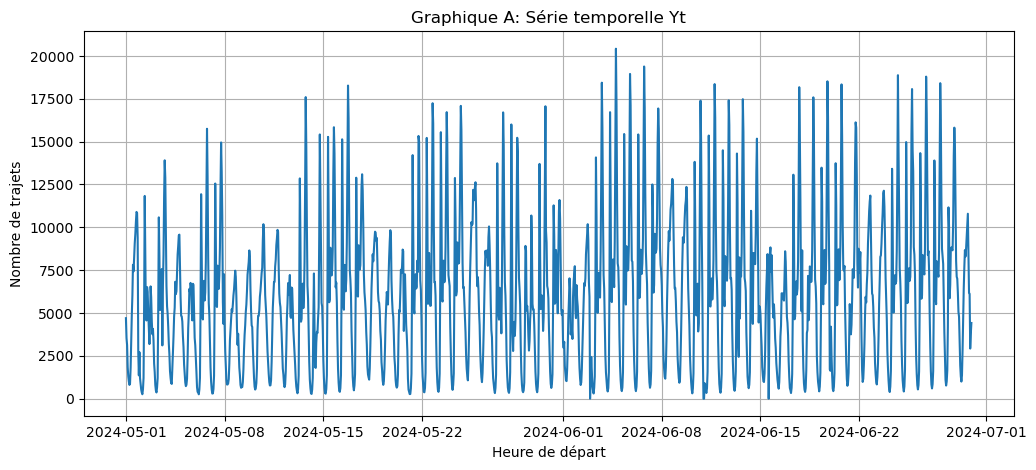

In [5]:

plt.figure(figsize=(12, 5))
plt.plot(Y)
plt.title("Graphique A: Série temporelle Yt")
plt.xlabel("Heure de départ")
plt.ylabel("Nombre de trajets")
plt.grid(True)
plt.show()

---

# Recherche d'une tendance polynomiale

In [6]:
# test d'une tendance polynomiale de degré 2
t = np.arange(len(Y))
X = sm.add_constant(np.column_stack([t, t**2]))
mod = sm.OLS(Y.values, X).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     16.02
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.31e-07
Time:                        18:10:13   Log-Likelihood:                -14040.
No. Observations:                1440   AIC:                         2.809e+04
Df Residuals:                    1437   BIC:                         2.810e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4643.9467    328.082     14.155      0.0

- la tendance quadratique n’est pas retenue car $t^2$ a une p-value de 0.177, donc non significative.
- la tendance linéaire est significative car $t$ a une p-value de 0.007, mais R-squared=0.022, donc elle explique seulement 2.2 % de la variabilité.

In [7]:
# retrait de la tendance polynomiamle de degrès 1

X = sm.add_constant(t)
mod_lin = sm.OLS(Y.values, X).fit()
y_sans_tendance = Y - mod_lin.fittedvalues

---

# Recherche de saisonnalité

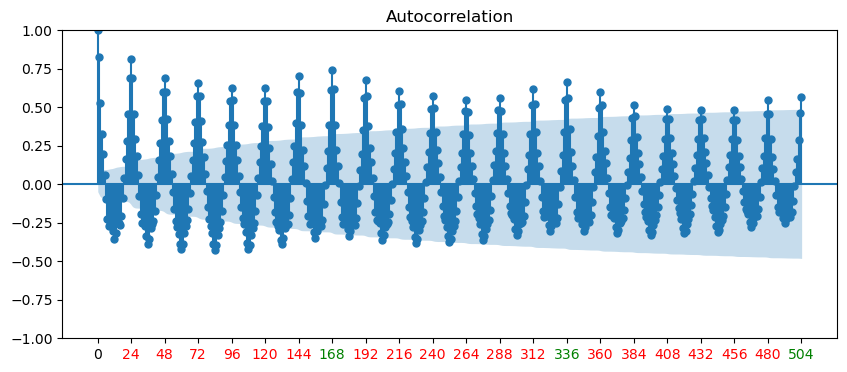

In [ ]:

fig, ax = plt.subplots(figsize=(10,4))
plot_acf(Y, lags=24*21, ax=ax) #fonction d'autocorrélation de Y

# graduations : tous les multiples de 24
xticks = np.arange(0, 24*21 + 1, 24)
ax.set_xticks(xticks)

# forcer l'affichage avant de modifier les couleurs
plt.draw()

# couleur des labels
for tick, val in zip(ax.get_xticklabels(), xticks):
    if val % 168 == 0 and val != 0:
        tick.set_color("green")
    elif val % 24 == 0 and val != 0:
        tick.set_color("red")

plt.show()

On observe une saisonnalité journalière (indices rouges) et hebdomadaire (inidece vert) .

In [22]:
# retrait de la saisonnalité

Y_diff24 = y_sans_tendance.diff(24)
Y_diff168= Y_diff24.diff(168)
Y_model= Y_diff168.dropna()

---

# Etude plus détaillée de la saisonnalité

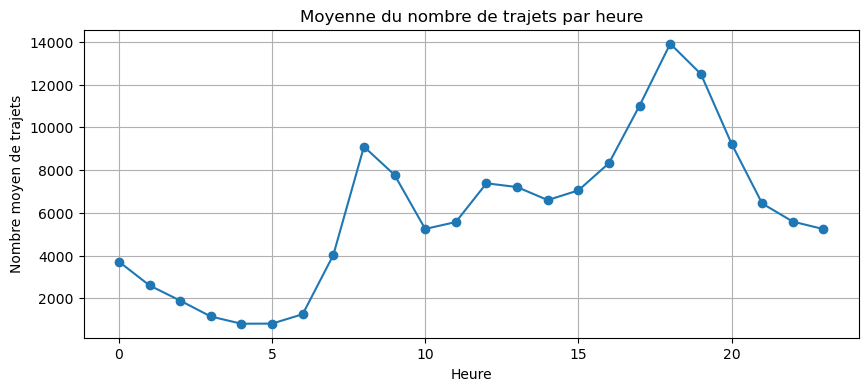

In [10]:
profil_horaire = Y.groupby(Y.index.hour).mean()

plt.figure(figsize=(10,4))
plt.plot(profil_horaire.index, profil_horaire.values, marker="o")
plt.title("Moyenne du nombre de trajets par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre moyen de trajets")
plt.grid(True)
plt.show()

On observe une dépendance à l'heure de la journée: heure de pointe matin et soir

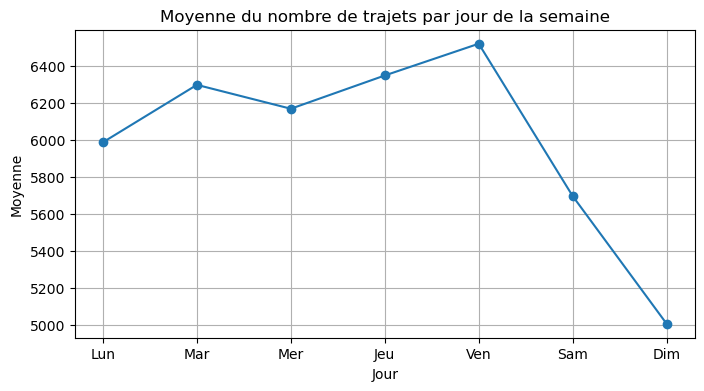

In [11]:
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
profil_semaine = Y.groupby(Y.index.dayofweek).mean()

plt.figure(figsize=(8,4))
plt.plot(jours, profil_semaine.values, marker="o")
plt.title("Moyenne du nombre de trajets par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Moyenne")
plt.grid(True)
plt.show()

On observe une dépendance importante au jour de la semaine: baisse importante le weekend

---

# Vérification finale de la stationnarité

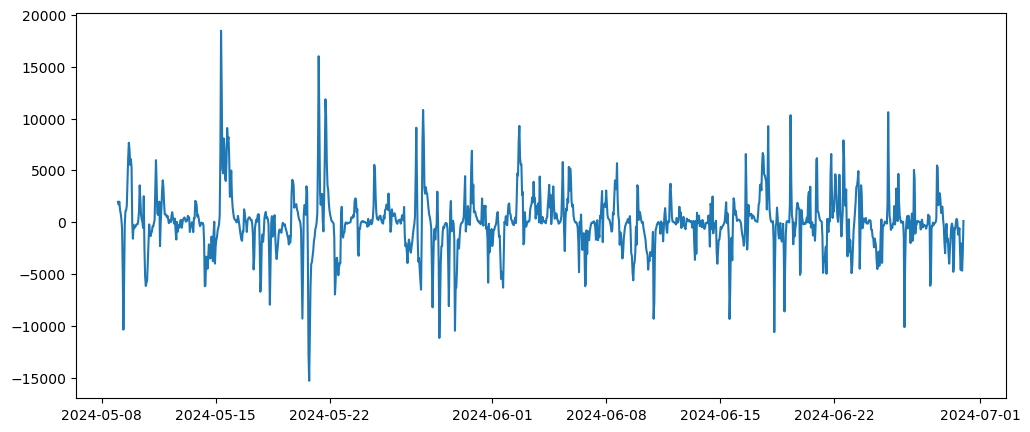

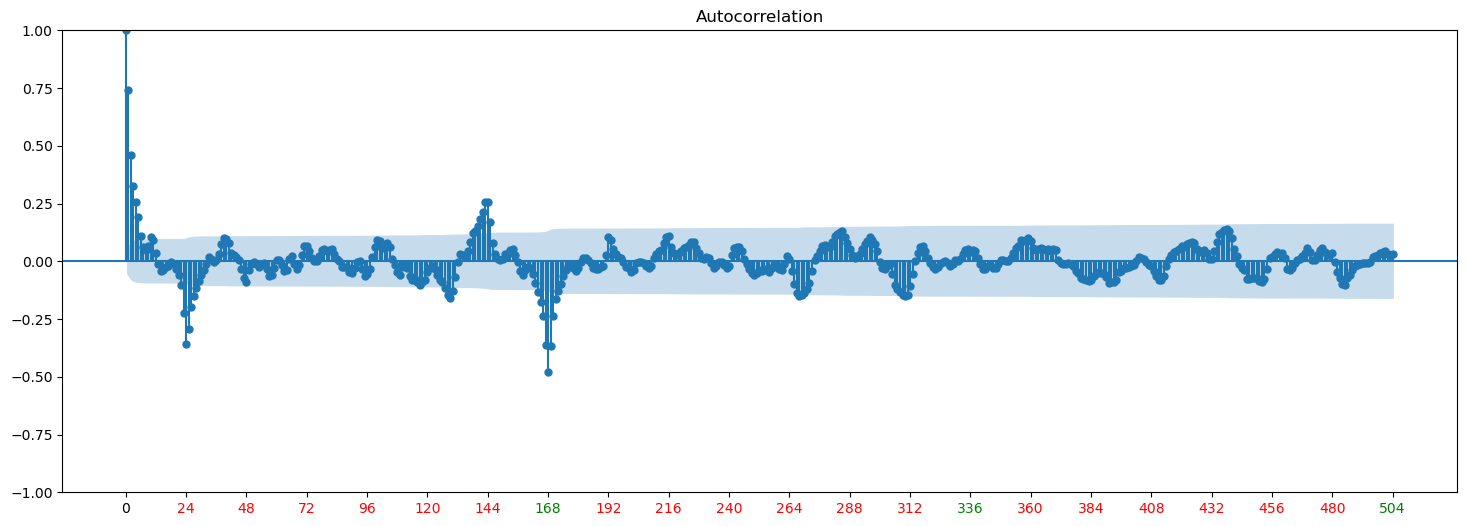

In [29]:

plt.figure(figsize=(12, 5))
plt.plot(Y_model)

fig, ax = plt.subplots(figsize=(18, 6))
plot_acf(Y_model, lags=24*21,ax=ax)

# graduations : tous les multiples de 24
xticks = np.arange(0, 24*21 + 1, 24)
ax.set_xticks(xticks)

# forcer l'affichage avant de modifier les couleurs
plt.draw()

# couleur des labels
for tick, val in zip(ax.get_xticklabels(), xticks):
    if val % 168 == 0 and val != 0:
        tick.set_color("green")
    elif val % 24 == 0 and val != 0:
        tick.set_color("red")
plt.show()

La nouvelle série semble à présent stationnaire


---

### Ajustement d'un modèle ARMA

In [ ]:
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore")

p = range(0, 3)
q = range(0, 3)

resultats = []

for i, j in itertools.product(p, q):
    try:
        mod = sm.tsa.ARIMA(Y_model, order=(i, 0, j))
        res = mod.fit()

        if res.mle_retvals.get("converged", False):
            resultats.append({
                "p": i,
                "q": j,
                "modele": f"ARMA({i},{j})",
                "AIC": res.aic
            })

    except Exception:
        continue

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values("AIC").reset_index(drop=True)

print("Tableau des modèles classés par AIC :")
display(df_resultats)

p_opt = int(df_resultats.loc[0, "p"])
q_opt = int(df_resultats.loc[0, "q"])
modele_opt = df_resultats.loc[0, "modele"]
aic_opt = df_resultats.loc[0, "AIC"]

print("Meilleur modèle retenu :", modele_opt)
print("AIC =", aic_opt)

res_final = sm.tsa.ARIMA(Y_model, order=(p_opt, 0, q_opt)).fit()
print(res_final.summary())

Tableau des modèles classés par AIC :


,p,q,modele,AIC
0,1,2,"ARMA(1,2)",22316.961553
1,2,2,"ARMA(2,2)",22317.544521
2,2,1,"ARMA(2,1)",22319.345669
3,1,1,"ARMA(1,1)",22321.088259
4,2,0,"ARMA(2,0)",22341.217676
5,1,0,"ARMA(1,0)",22388.118839
6,0,2,"ARMA(0,2)",22404.063967
7,0,1,"ARMA(0,1)",22578.068838
8,0,0,"ARMA(0,0)",23377.442634


Meilleur modèle retenu : ARMA(1,2)
AIC = 22316.961552697776
                               SARIMAX Results                                
Dep. Variable:         nombre_trajets   No. Observations:                 1248
Model:                 ARIMA(1, 0, 2)   Log Likelihood              -11153.481
Date:                Fri, 03 Apr 2026   AIC                          22316.962
Time:                        11:28:05   BIC                          22342.608
Sample:                    05-09-2024   HQIC                         22326.604
                         - 06-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.3502    190.549      0.033      0.973    -367.118     379.819
ar.L1          0.7014      0.048     14.589      0.000       0.607     



Parmi les différents modèles testés, le modèle ARMA(1,2) est celui qui minimise le critère AIC. Il est donc retenu comme le meilleur modèle.

Les coefficients estimés sont significatifs, ce qui montre que la dépendance au passé et aux erreurs passées est bien prise en compte par le modèle. En revanche, la constante n’est pas significative.

L’analyse des résidus (test de Ljung-Box non significatif) montre qu’il n’y a plus d’autocorrélation, ce qui est un point positif. Même si les résidus ne sont pas parfaitement normaux et qu’il existe une légère hétéroscédasticité, le modèle reste globalement satisfaisant.

On peut donc utiliser ce modèle pour la suite de l’analyse..

Afin de valider le modèle, plusieurs tests sont réalisés sur les résidus. Le test de Ljung-Box permet de vérifier l’absence d’autocorrélation, le test de Shapiro-Wilk la normalité, et le test ARCH l’homoscédasticité. Les résultats sont résumés dans le tableau ci-dessous.

---

### Analyse des résidus

In [17]:
residus = res_final.resid

# tests
ljung = acorr_ljungbox(residus, lags=[10], return_df=True)
shap_stat, shap_p = shapiro(residus)

#  tableau des résultats des tests
df_tests = pd.DataFrame({
    "Test": ["Ljung-Box", "Shapiro-Wilk"],
    "Statistique": [
        round(ljung["lb_stat"].values[0], 2),
        round(shap_stat, 2)
    ],
    "p-value": [
        round(ljung["lb_pvalue"].values[0], 2),
        round(shap_p, 2)
    ]
})

print(df_tests)

           Test  Statistique  p-value
0     Ljung-Box        22.07     0.01
1  Shapiro-Wilk         0.87     0.00



Les graphiques de diagnostic permettent de vérifier visuellement la qualité du modèle. On observe que les résidus ne présentent pas de structure particulière et se comportent comme un bruit blanc.

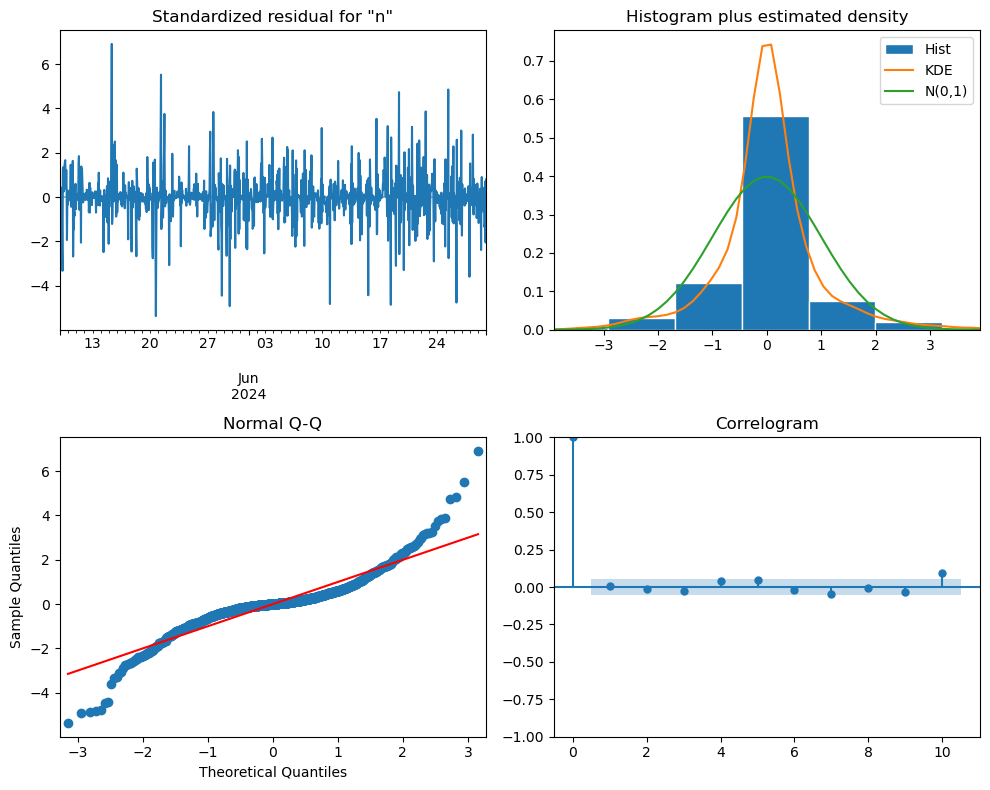

In [18]:
fig = res_final.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()

---

### Performance du modèle en prévision

In [ ]:
n = len(Y)
T=int(0.8*n)
#séparation donnée entrainement et test
train = Y_model.iloc[:T]
test = Y_model.iloc[T:]

#modélisation des données d'entrainement
model_train = sm.tsa.ARIMA(train, order=(1,0,2)).fit()

#prédiction de la taille des données de test à comparer
pred = model_train.forecast(steps=len(test))

#comparaison avec les données de test
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 1486.2233343366488
RMSE : 2332.710640609487


- Le MAE signifie qu’en moyenne, l’erreur absolue de prévision est d’environ 1486 trajets par heure.
- Le RMSE est plus grand que le MAE, donc certaines erreurs sont nettement plus fortes que la moyenne

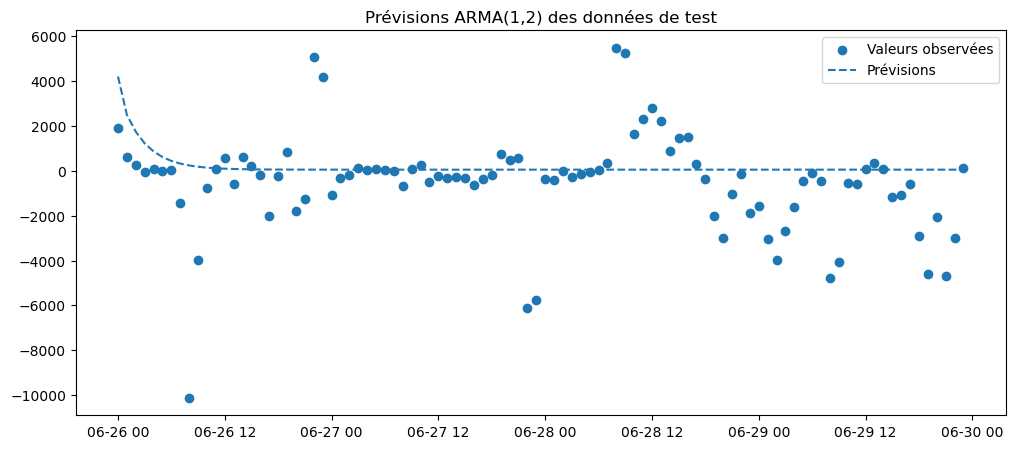

In [30]:
plt.figure(figsize=(12,5))
plt.scatter(test.index, test, label="Valeurs observées")
plt.plot(test.index, pred, label="Prévisions", linestyle="--")
plt.legend()
plt.title("Prévisions ARMA(1,2) des données de test")
plt.show()